**Context**

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

**Objective**

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and to identify which segment of customers to target more.

# Personal Loan Campaign *(by Prateek)*

### Importing necessary libarires

In [21]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
import pgeocode

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To perform statistical analysis
import scipy.stats as stats

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)
import folium

# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

## Objective
- Build a Predictive Model to reach out to customers for Personal Loan using the important attributes in the data.
- Identify segments of customer for maximum loan campaign conversion.


### Reading and Viewing raw data

In [2]:
#Reading data
dt=pd.read_csv("Loan_Modelling.csv")

In [3]:
#Making a copying for any raw data requirement
dt1=dt.copy()

In [4]:
dt.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### Checking for null, duplicates and data quality/type

In [5]:
#Checking for null values
dt.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

In [6]:
#Checking duplicates
dt.duplicated().sum()

np.int64(0)

In [7]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [8]:
dt.shape

(5000, 14)

### Statistical Summary of Data

In [9]:
dt.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


### Observation
-  There are 5k rows and 14 columns.
-  13 integer and 1 float data type.
-  Average individual have an age of 45 yrs with 20 yrs of work experience and 64k USD as annual salary with 2 family members.


### Exploratory Data Analysis(EDA)

In [10]:
#Converting ZIP Codes into city and state for better customer profiling and demographic insights
nomi = pgeocode.Nominatim('us')
dt["City"] = dt["ZIPCode"].apply(lambda x: nomi.query_postal_code(x).place_name)
dt["State"] = dt["ZIPCode"].apply(lambda x: nomi.query_postal_code(x).state_name)

#### Replacing -Ve Experience with 0 

In [11]:
dt["Experience"] = dt["Experience"].clip(lower=0)
(dt["Experience"]<0).sum()

np.int64(0)

In [12]:
dt.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,City,State
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,Pasadena,California
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,Los Angeles,California
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,Berkeley,California
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,San Francisco,California
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,Northridge,California


In [13]:
#Checking for Null City,State information
dt[dt["City"].isnull()].groupby("ZIPCode").size()
#we can keep them as is because of the percent(41/5000 < ~1%)

ZIPCode
92634     5
92709     7
92717    22
93077     1
96651     6
dtype: int64

In [14]:
dt[dt["Personal_Loan"]==1].shape[0]
# (480/5000=9.6%)Customers lended money based on marketing campaign/
#Skewed labels for lenders vs Non lenders,split the train/test data very consciously.

480

#### Creating Buckets for attributes for better visualization

In [15]:
#Bucketing Attributes Income,CCAvg,Age,Experience for better visualization

dt["Income_cat"] = pd.cut(
dt["Income"],
bins=[-np.inf, 50, 100, np.inf],
labels=["0-50", "51-100", "101+"])

dt["CCAvg_cat"] = pd.cut(
dt["CCAvg"],
bins=[-np.inf, 1, 2, 3, 4, np.inf],
labels=["0-1", "1-2", "2-3", "3-4", "4+"])

dt["Age_cat"] = pd.cut(
dt["Age"],
bins=[20, 30, 40, 50, 60, 70],
labels=["20-30", "31-40", "41-50", "51-60", "61-70"])

dt["Experience_cat"] = pd.cut(
dt["Experience"],
bins=[-np.inf, 10, 20, 30, 40, 50],
labels=["<10", "11-20", "21-30", "31-40", "41-50"])

## Univariate Analysis

In [22]:
num_cols = dt.columns.drop(["ID","CCAvg","Income","Mortgage","Age","Experience","ZIPCode","City"])

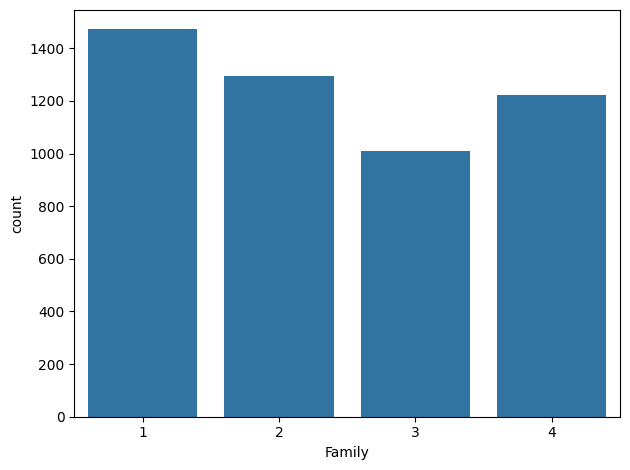

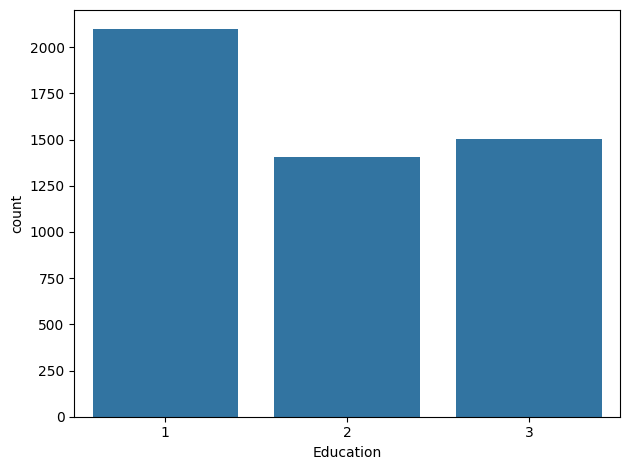

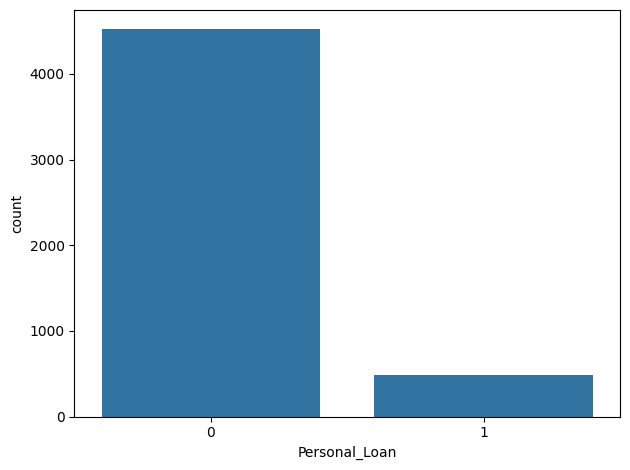

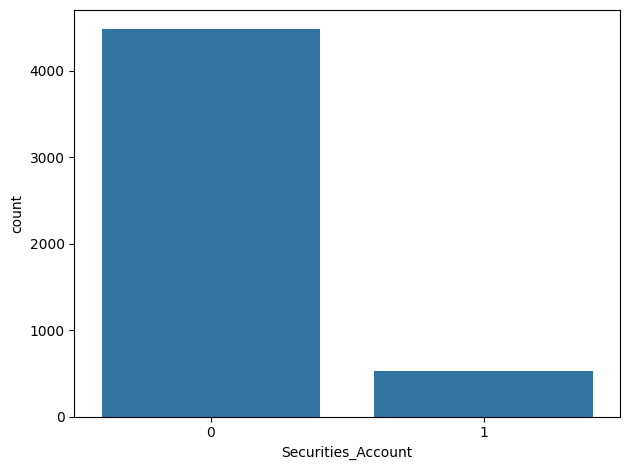

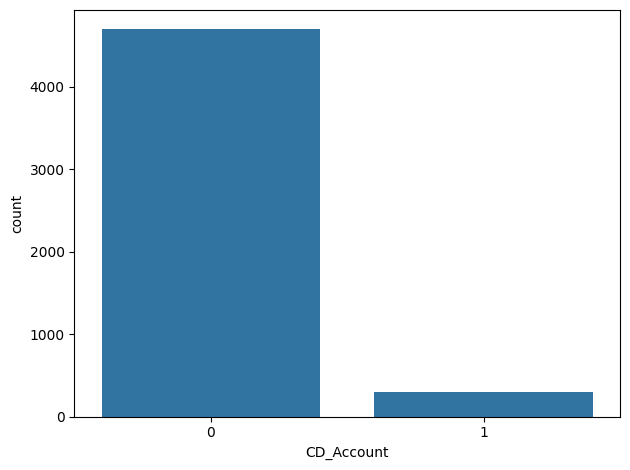

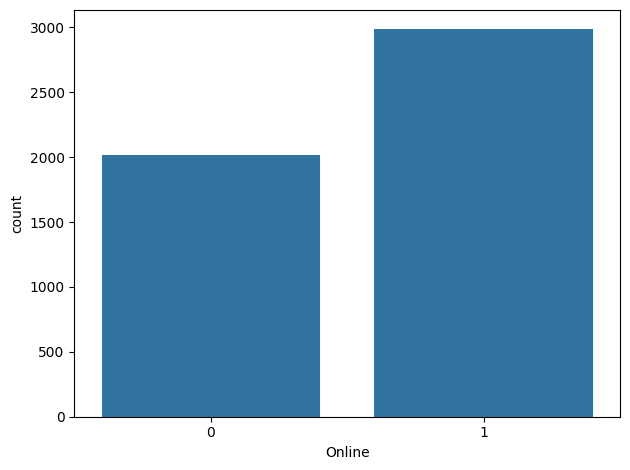

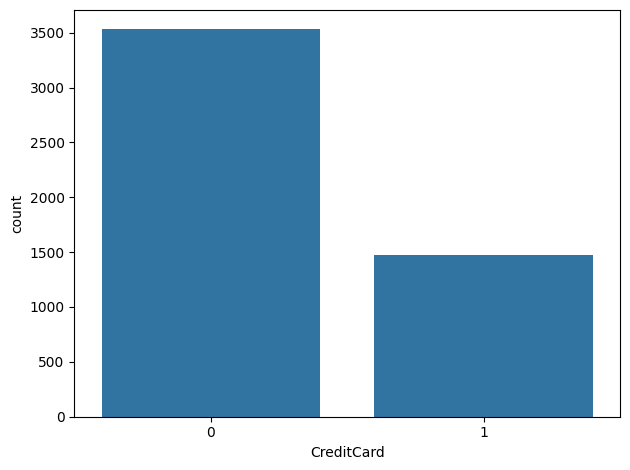

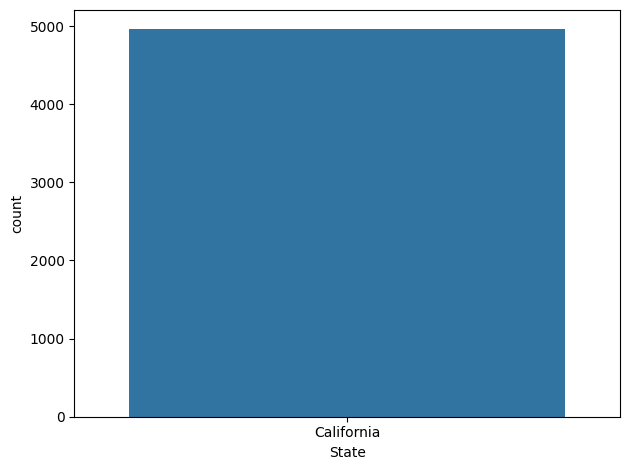

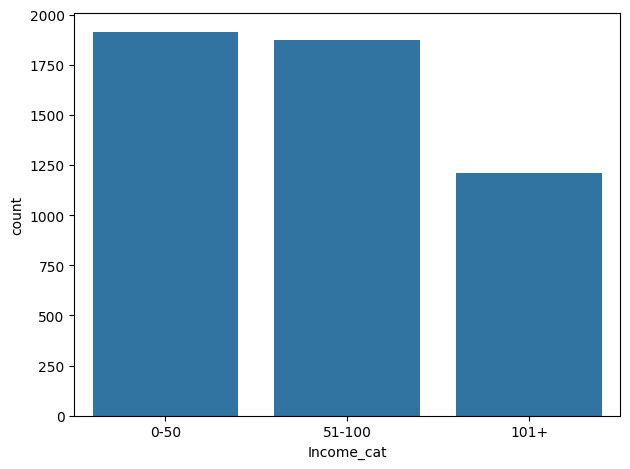

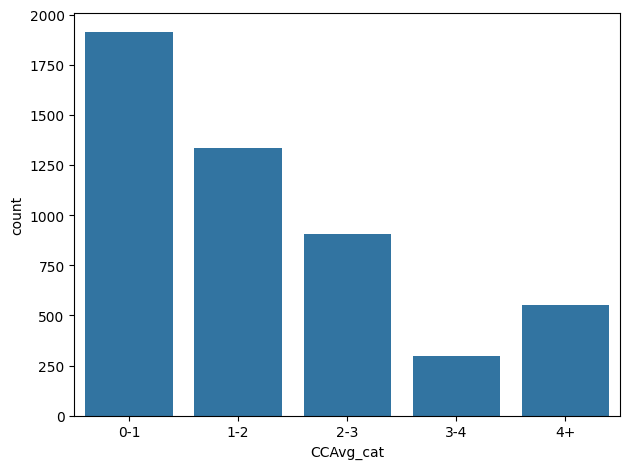

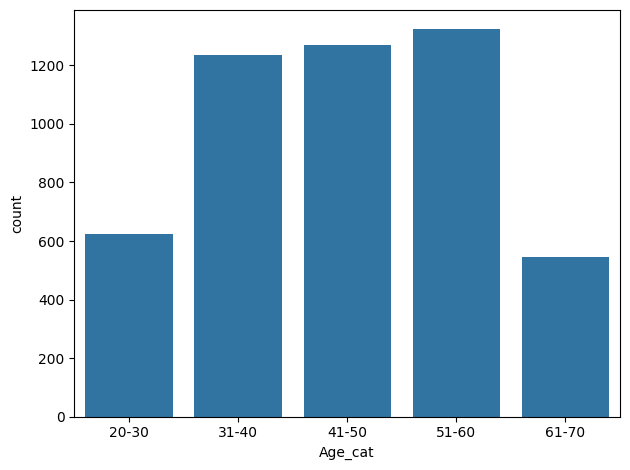

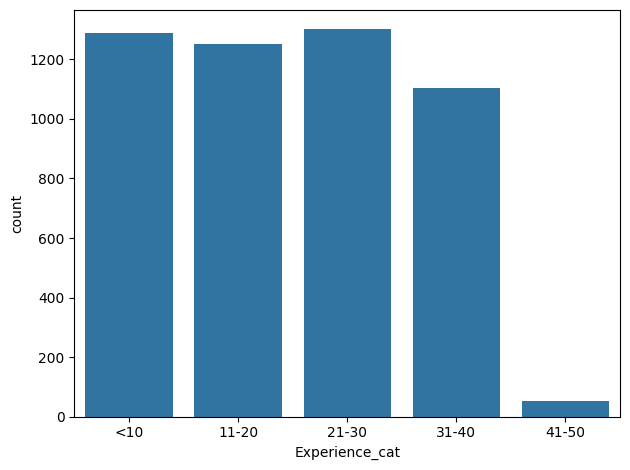

In [23]:
for i in num_cols:
 sns.countplot(data=dt, x=i)
 plt.tight_layout()
 plt.show()

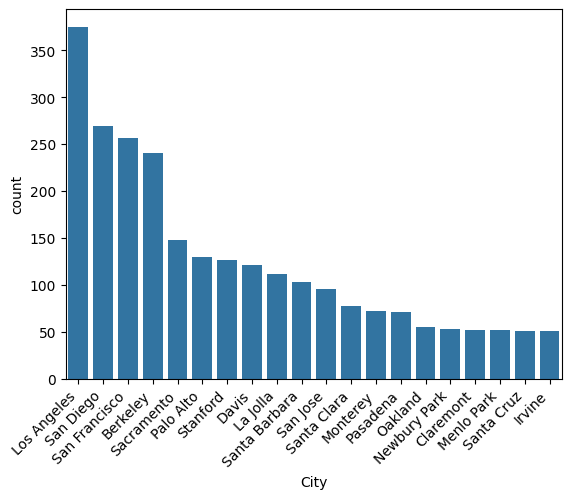

In [18]:
valid_city = (dt["City"].value_counts().loc[lambda x: x > 50].index)
dt_filtered = dt[dt["City"].isin(valid_city)]
dt_filtered["City_Count"] = dt_filtered.groupby("City")["City"].transform("count")
dt_filtered = dt_filtered.sort_values(by="City_Count", ascending=False)
sns.countplot(data=dt_filtered,x="City")
plt.xticks(rotation=45, ha='right')
plt.show()

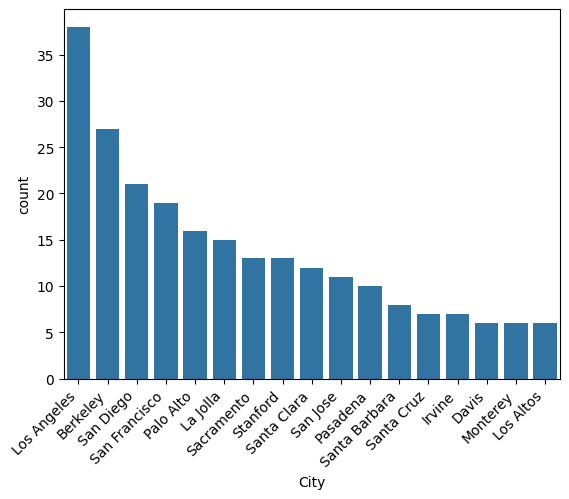

In [19]:
valid_city_personal_loan=dt[dt["Personal_Loan"]==1]
valid_city_personal_loan1= (valid_city_personal_loan["City"].value_counts().loc[lambda x: x > 5].index)
valid_city_personal_loan2=valid_city_personal_loan[valid_city_personal_loan["City"].isin(valid_city_personal_loan1)]
valid_city_personal_loan2["City_Count"] = valid_city_personal_loan2.groupby("City")["City"].transform("count")
valid_city_personal_loan2 = valid_city_personal_loan2.sort_values(by="City_Count", ascending=False)
sns.countplot(data=valid_city_personal_loan2,x="City")
plt.xticks(rotation=45, ha='right')
plt.show()

### Observations
- Undergrad population is greater than Grad &Advanced/Professional.
- Online banking facilities are being used very widely and more than offline.
- Los Angeles has both more customers and customers with personal loan.

### Visualizing Cities on World Map

In [24]:
cal_zip = dt[dt["State"] == "California"]
zip_customer_count = cal_zip.groupby("ZIPCode").size().reset_index(name="Customer_Count")

zip_count = dt.groupby("ZIPCode").size().reset_index(name="Customer_Count")

nomi = pgeocode.Nominatim('us')

zip_count["lat"] = zip_count["ZIPCode"].apply(lambda x: nomi.query_postal_code(x).latitude)
zip_count["lon"] = zip_count["ZIPCode"].apply(lambda x: nomi.query_postal_code(x).longitude)

zip_count = zip_count.dropna(subset=["lat", "lon"])

def get_color(count):
    if count <= 5:
        return "green"       # Low
    elif count <= 15:
        return "orange"      # Medium
    else:
        return "red"         # High

m = folium.Map(location=[37.09, -95.71], zoom_start=4)

for _, row in zip_count.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5 + row["Customer_Count"] * 0.1,   # size also changes
        color=get_color(row["Customer_Count"]),
        fill=True,
        fill_color=get_color(row["Customer_Count"]),
        fill_opacity=0.7,
        popup=f"""
        ZIP: {row['ZIPCode']}<br>
        Customers: {row['Customer_Count']}
        """
    ).add_to(m)

m

In [88]:
num_cols1 = dt1.columns.drop(["ID","ZIPCode","Personal_Loan","Securities_Account"
                             ,"CD_Account","Online","CreditCard"])

In [89]:
num_cols1

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage'],
      dtype='object')

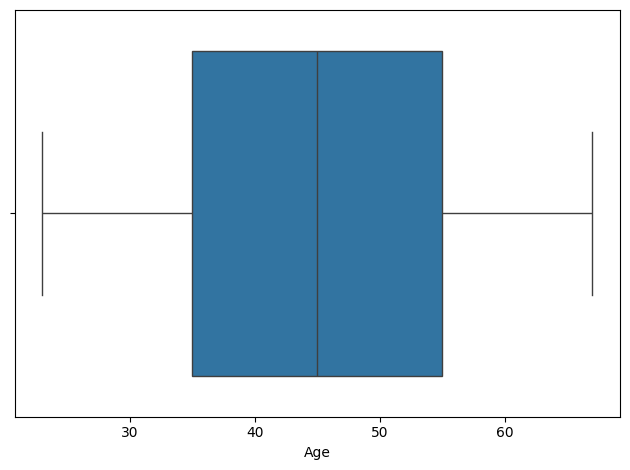

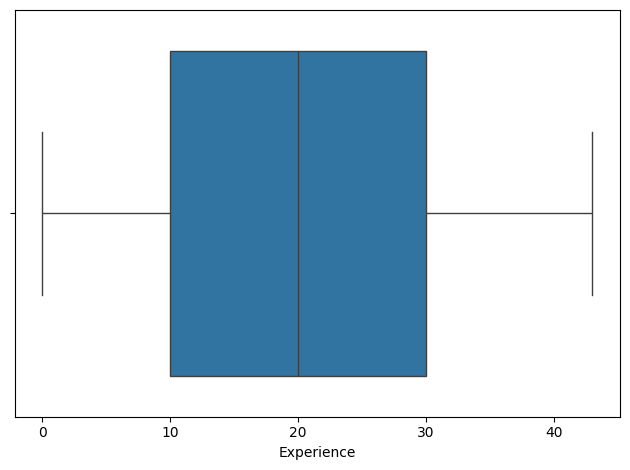

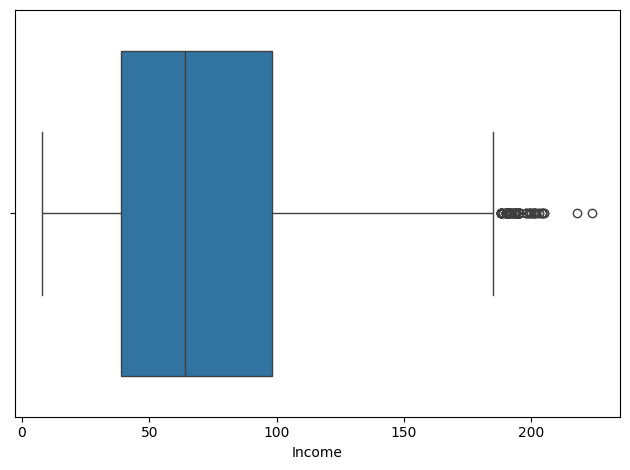

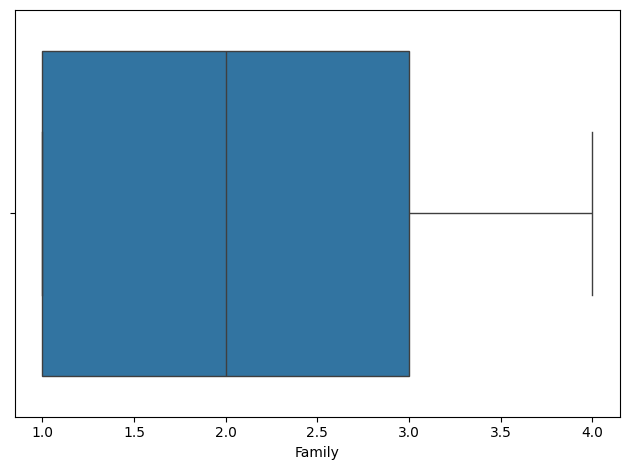

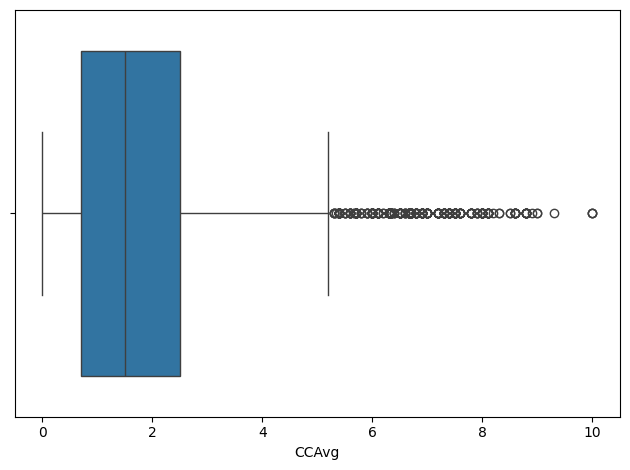

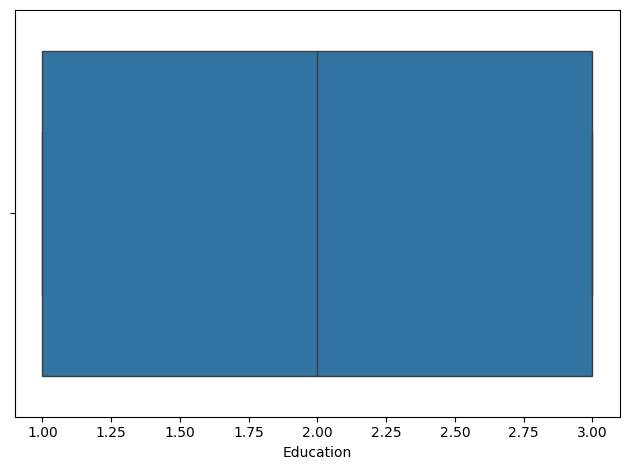

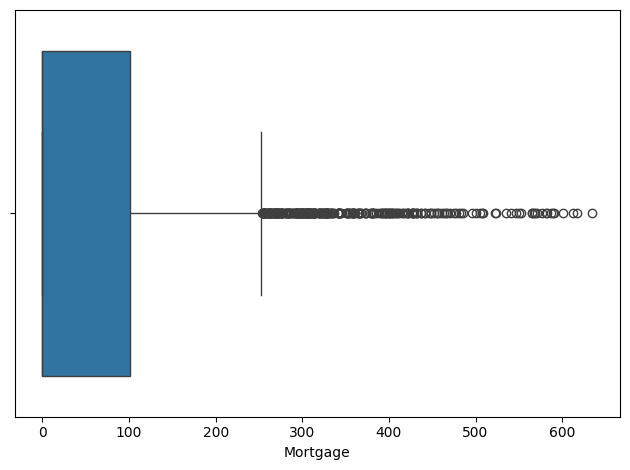

In [90]:
for i in num_cols1:
 sns.boxplot(data=dt, x=i)
 plt.tight_layout()
 plt.show()

#### Checking for customers where Credit card spent is greater than Income

In [93]:
dt1[dt1["CCAvg"]>dt1["Income"]]

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard


In [109]:
print("Customer with Debt-Income ratio greater than 5 :",dt1[(dt1["Mortgage"]>dt1["Income"]) & (dt1["Mortgage"]/dt1["Income"]>5)].shape[0])
print("Customer with Debt-Income ratio greater than 10 :",dt1[(dt1["Mortgage"]>dt1["Income"]) & (dt1["Mortgage"]/dt1["Income"]>10)].shape[0])

Customer with Debt-Income ratio greater than 5 : 172
Customer with Debt-Income ratio greater than 10 : 14


## Observation
- Customer with Debt-Income ratio greater than 5 : 172
- Customer with Debt-Income ratio greater than 10 : 14

## Bivariate Analysis

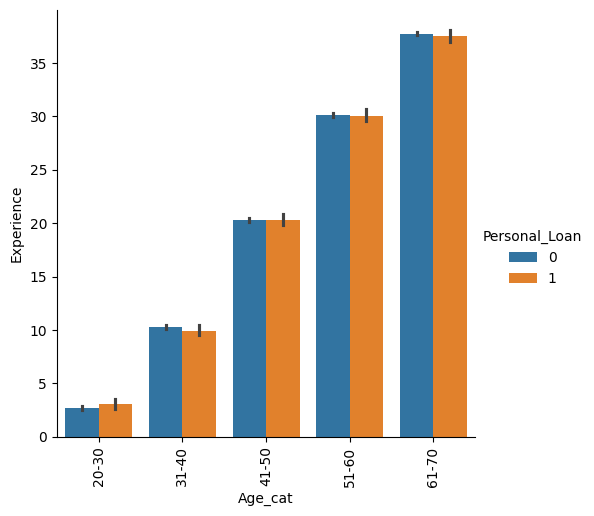

In [25]:
sns.catplot(data=dt,x="Age_cat",y="Experience",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

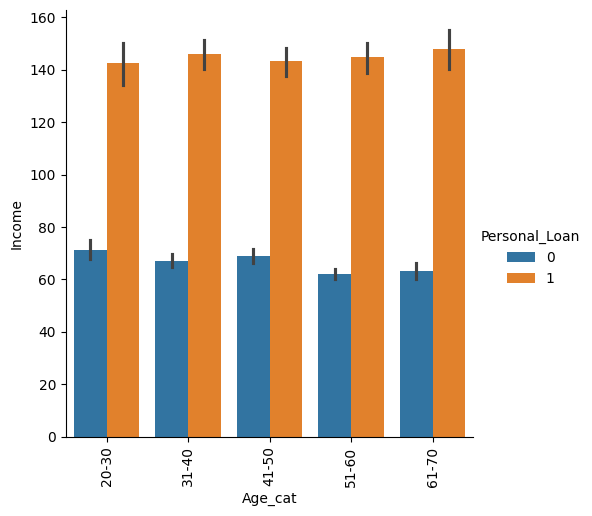

In [26]:
sns.catplot(data=dt,x="Age_cat",y="Income",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

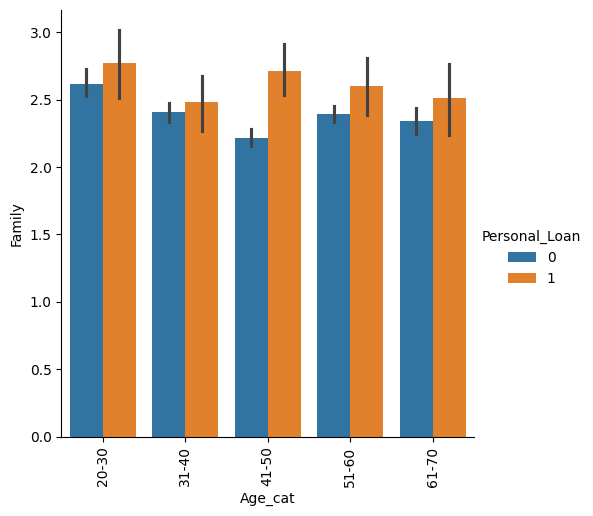

In [27]:
sns.catplot(data=dt,x="Age_cat",y="Family",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

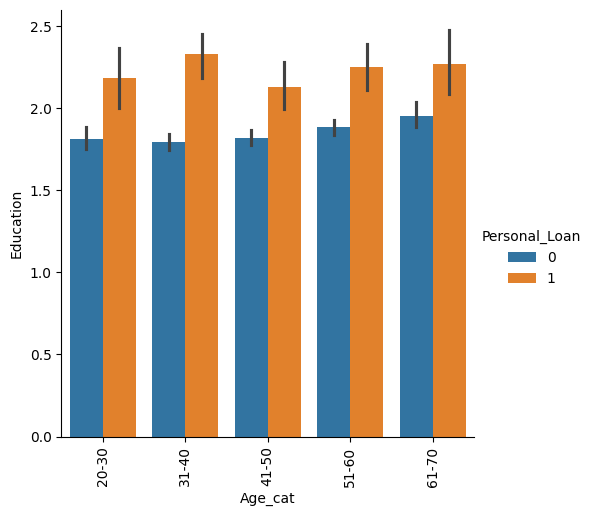

In [28]:
sns.catplot(data=dt,x="Age_cat",y="Education",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

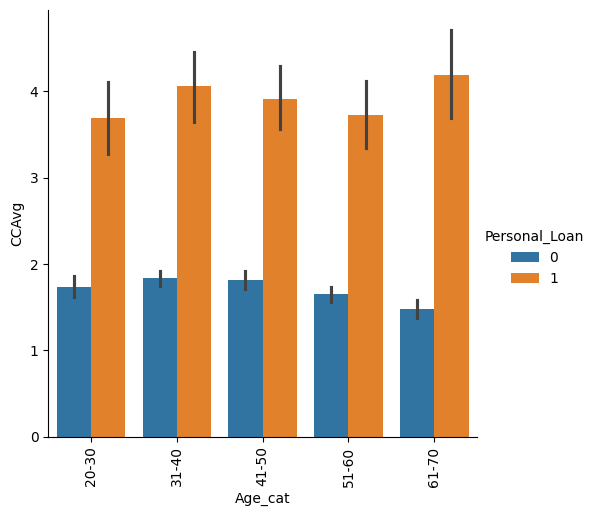

In [30]:
sns.catplot(data=dt,x="Age_cat",y="CCAvg",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

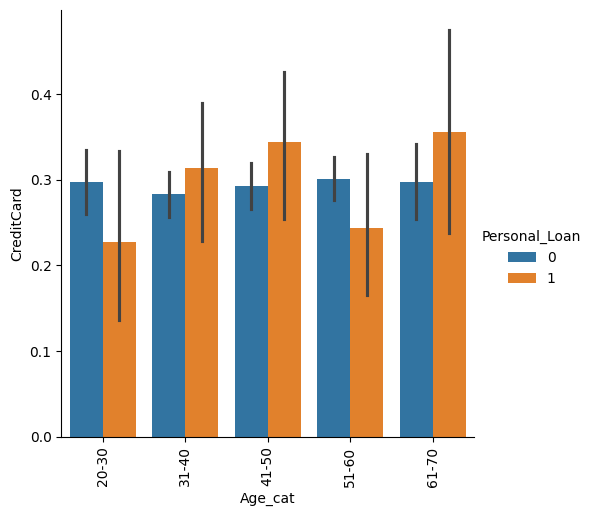

In [31]:
sns.catplot(data=dt,x="Age_cat",y="CreditCard",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

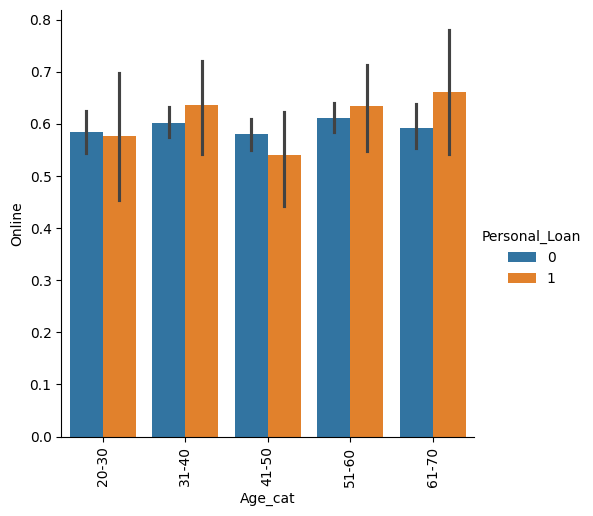

In [32]:
sns.catplot(data=dt,x="Age_cat",y="Online",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

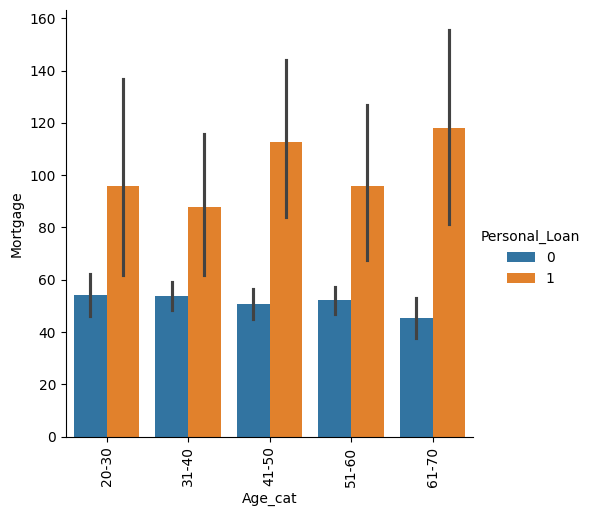

In [33]:
sns.catplot(data=dt,x="Age_cat",y="Mortgage",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

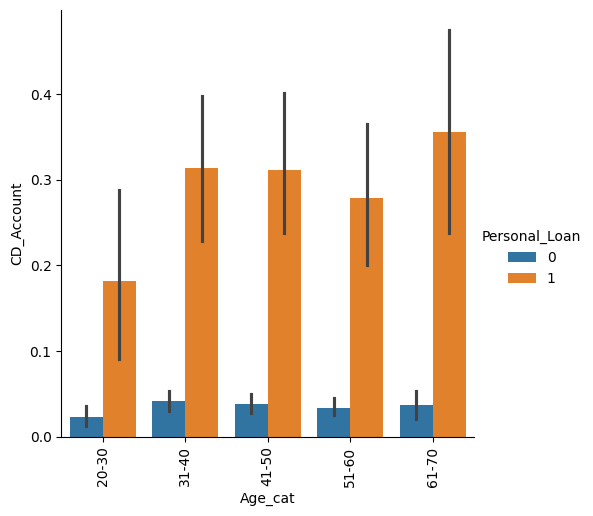

In [34]:
sns.catplot(data=dt,x="Age_cat",y="CD_Account",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

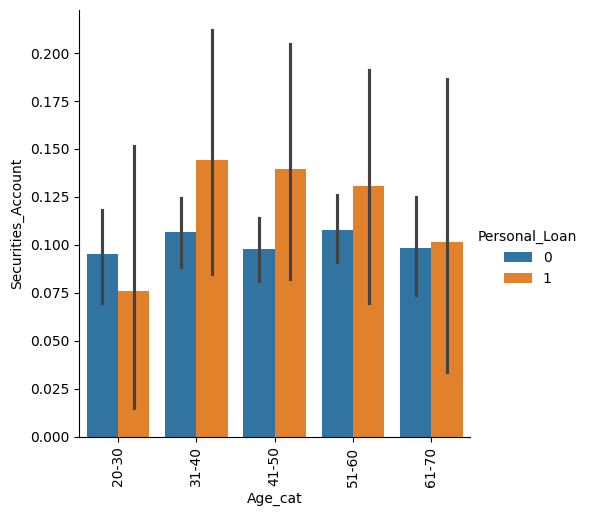

In [35]:
sns.catplot(data=dt,x="Age_cat",y="Securities_Account",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

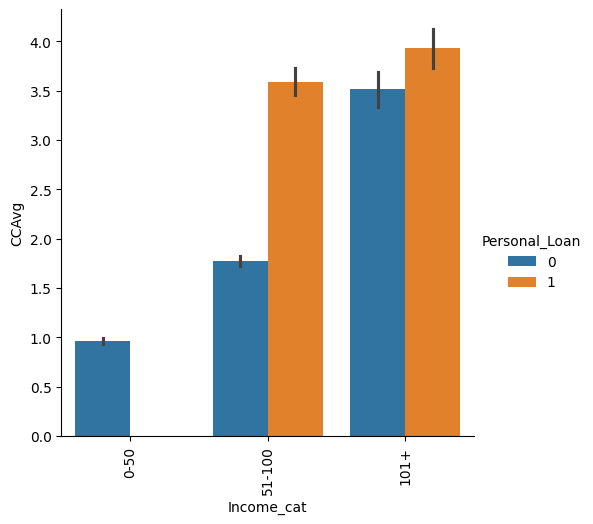

In [36]:
sns.catplot(data=dt,x="Income_cat",y="CCAvg",kind="bar",hue="Personal_Loan")
plt.xticks(rotation=90)
plt.show()

### Observaions
- Age & Experience follows a similar linear pattern.
- In different age category people with personal loan has more mean Income, Mortage,CD_Account, Education level,Credit card spent.

### Multivariate Analysis

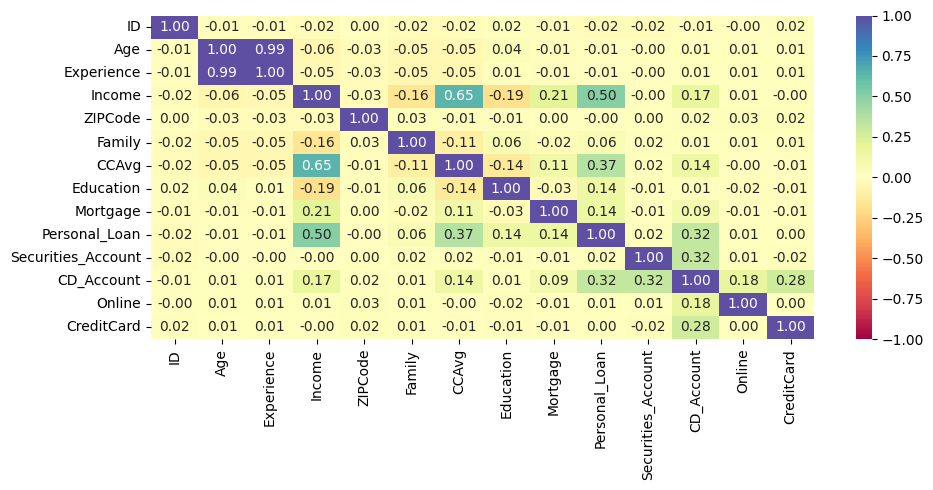

In [37]:
num_var = dt1.dtypes[dt1.dtypes != 'object'].index
corr = dt1[num_var].corr(numeric_only = True)
# plot the heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.tight_layout()
plt.show()

### Observation
- Income and Credit card spend show a strong corelation.
- Also customer with more income tend to take more personal loan.

### Data Preparation for Modeling

In [52]:
x=dt1.drop(["ID","Personal_Loan"],axis=1)
y=dt1["Personal_Loan"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y )# Using stratify for equal target value distribution.

In [39]:
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64


### Model Evaluation Criterion
#### It is better to contact more people and catch most potential buyers than to be too strict and miss them.
#### **Recall** will be used to judge Model Performance.

#### Functions for Evaluation, Confusion Matrix, Tree Visualization, Feature Importance

In [40]:
def evaluation_metric(model,pred,target):
    
    acc = accuracy_score(target, model.predict(pred))  # to compute Accuracy
    recall = recall_score(target, model.predict(pred))  # to compute Recall
    precision = precision_score(target, model.predict(pred))  # to compute Precision
    f1 = f1_score(target, model.predict(pred))  # to compute F1-score
    
    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
    {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},index=[0],)
    return df_perf

In [41]:
def confusion_matrix_sklearn(model, pred, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(pred)
    cm = confusion_matrix(y_pred,target)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [42]:
def vtree(model, pred, target):
    column_names = list(x.columns)
    feature_names = column_names
    
    plt.figure(figsize=(20, 30))
    out = tree.plot_tree(
        model,
        feature_names=feature_names,
        filled=True,
        fontsize=9,
        node_ids=True,
        class_names=True,
    )
    for o in out:
        arrow = o.arrow_patch
        if arrow is not None:
            arrow.set_edgecolor("black")
            arrow.set_linewidth(1)
    return plt.show()


In [54]:
def importance(model, pred, target):
    importances = model.feature_importances_
    indices = np.argsort(importances)
    
    plt.title("Feature Importances")
    plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
    column_names = list(x.columns)
    feature_names = column_names
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.show()

## Decision Tree(Default)

In [44]:
dtc=DecisionTreeClassifier(criterion="gini",class_weight="balanced",random_state=42)
dtc.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


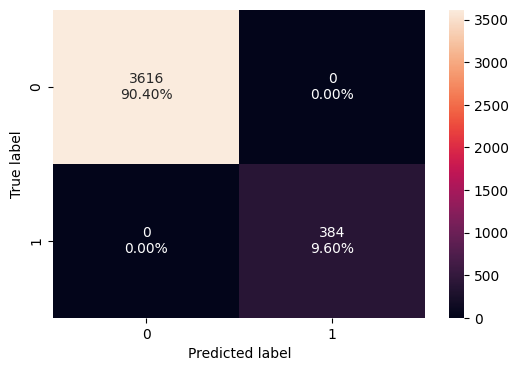

In [45]:
print(evaluation_metric(dtc,x_train,y_train))
confusion_matrix_sklearn(dtc,x_train,y_train)

   Accuracy    Recall  Precision    F1
0     0.984  0.958333   0.884615  0.92


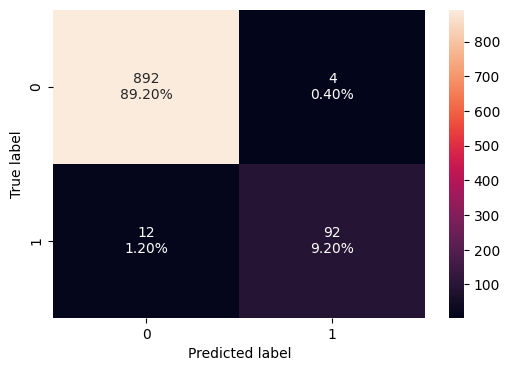

In [46]:
print(evaluation_metric(dtc,x_test,y_test))
confusion_matrix_sklearn(dtc,x_test,y_test)

## Visualizing Decision Tree(Default)

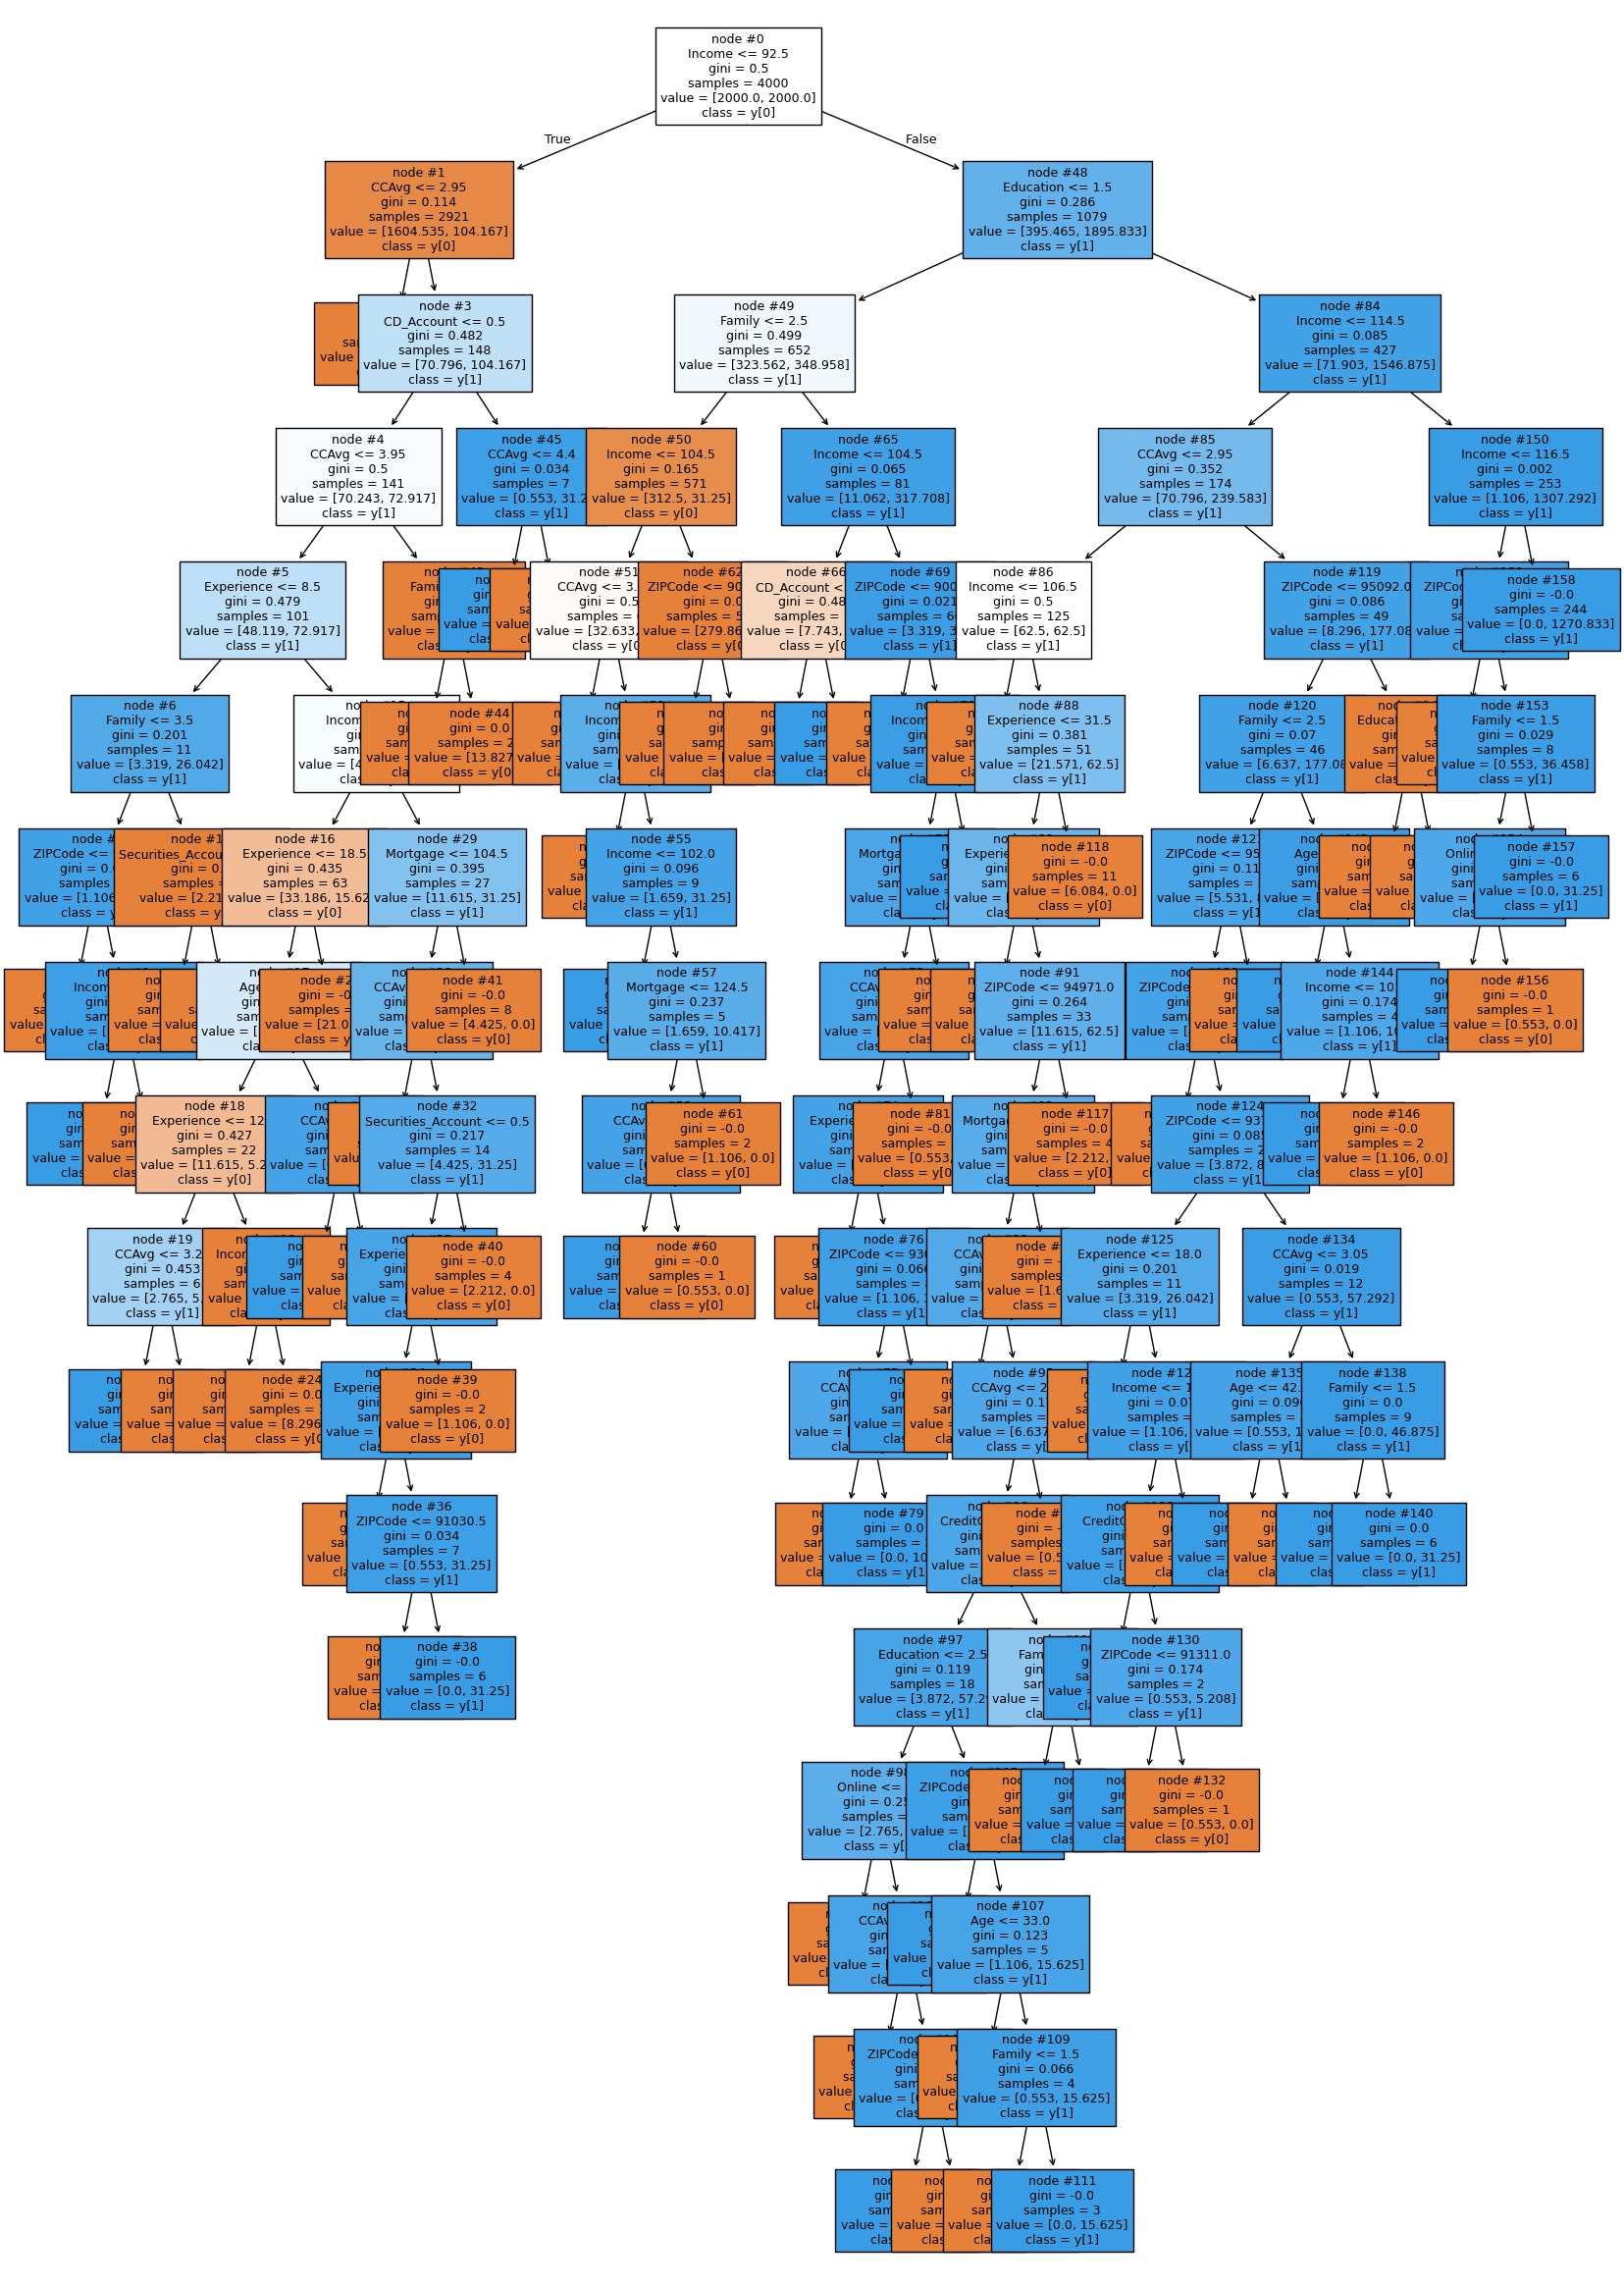

In [47]:
vtree(dtc,x_train,y_train)


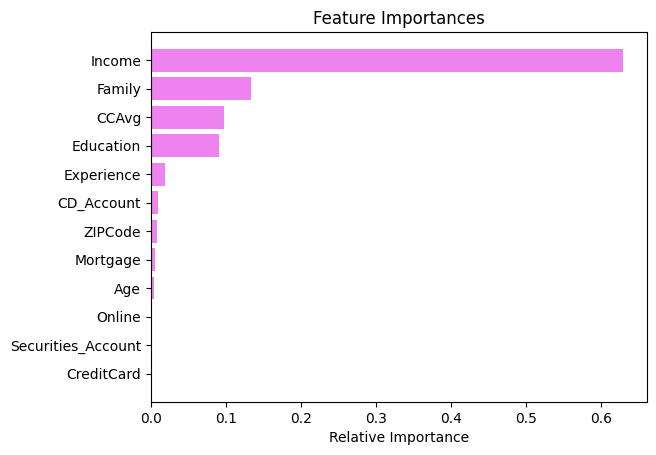

In [55]:
importance(dtc,x_train,y_train)

### Observations
+ Model is overfiting as Evaluation metric is 1 for all Train Data but **"<1"** for Test.

## Decision Tree(Pre-Pruning)

- Using Max depth, Max leaf nodes, Min sample split values to iterate for best recall.

In [56]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 1)
max_leaf_nodes_values = [10, 20, 30, 50]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(x_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(x_train)
            y_test_pred = estimator.predict(x_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# creating an instance of the best model
model1 = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 10
Min samples split: 10
Best test recall score: 1.0


   Accuracy  Recall  Precision        F1
0     0.778     1.0   0.301887  0.463768


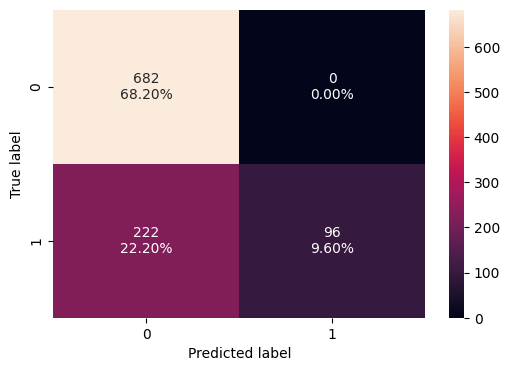

In [57]:
print(evaluation_metric(model1,x_test,y_test))
confusion_matrix_sklearn(model1,x_test,y_test)

   Accuracy  Recall  Precision        F1
0   0.78925     1.0   0.312958  0.476723


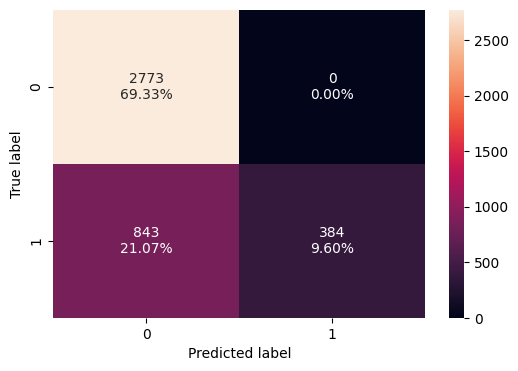

In [58]:
print(evaluation_metric(model1,x_train,y_train))
confusion_matrix_sklearn(model1,x_train,y_train)

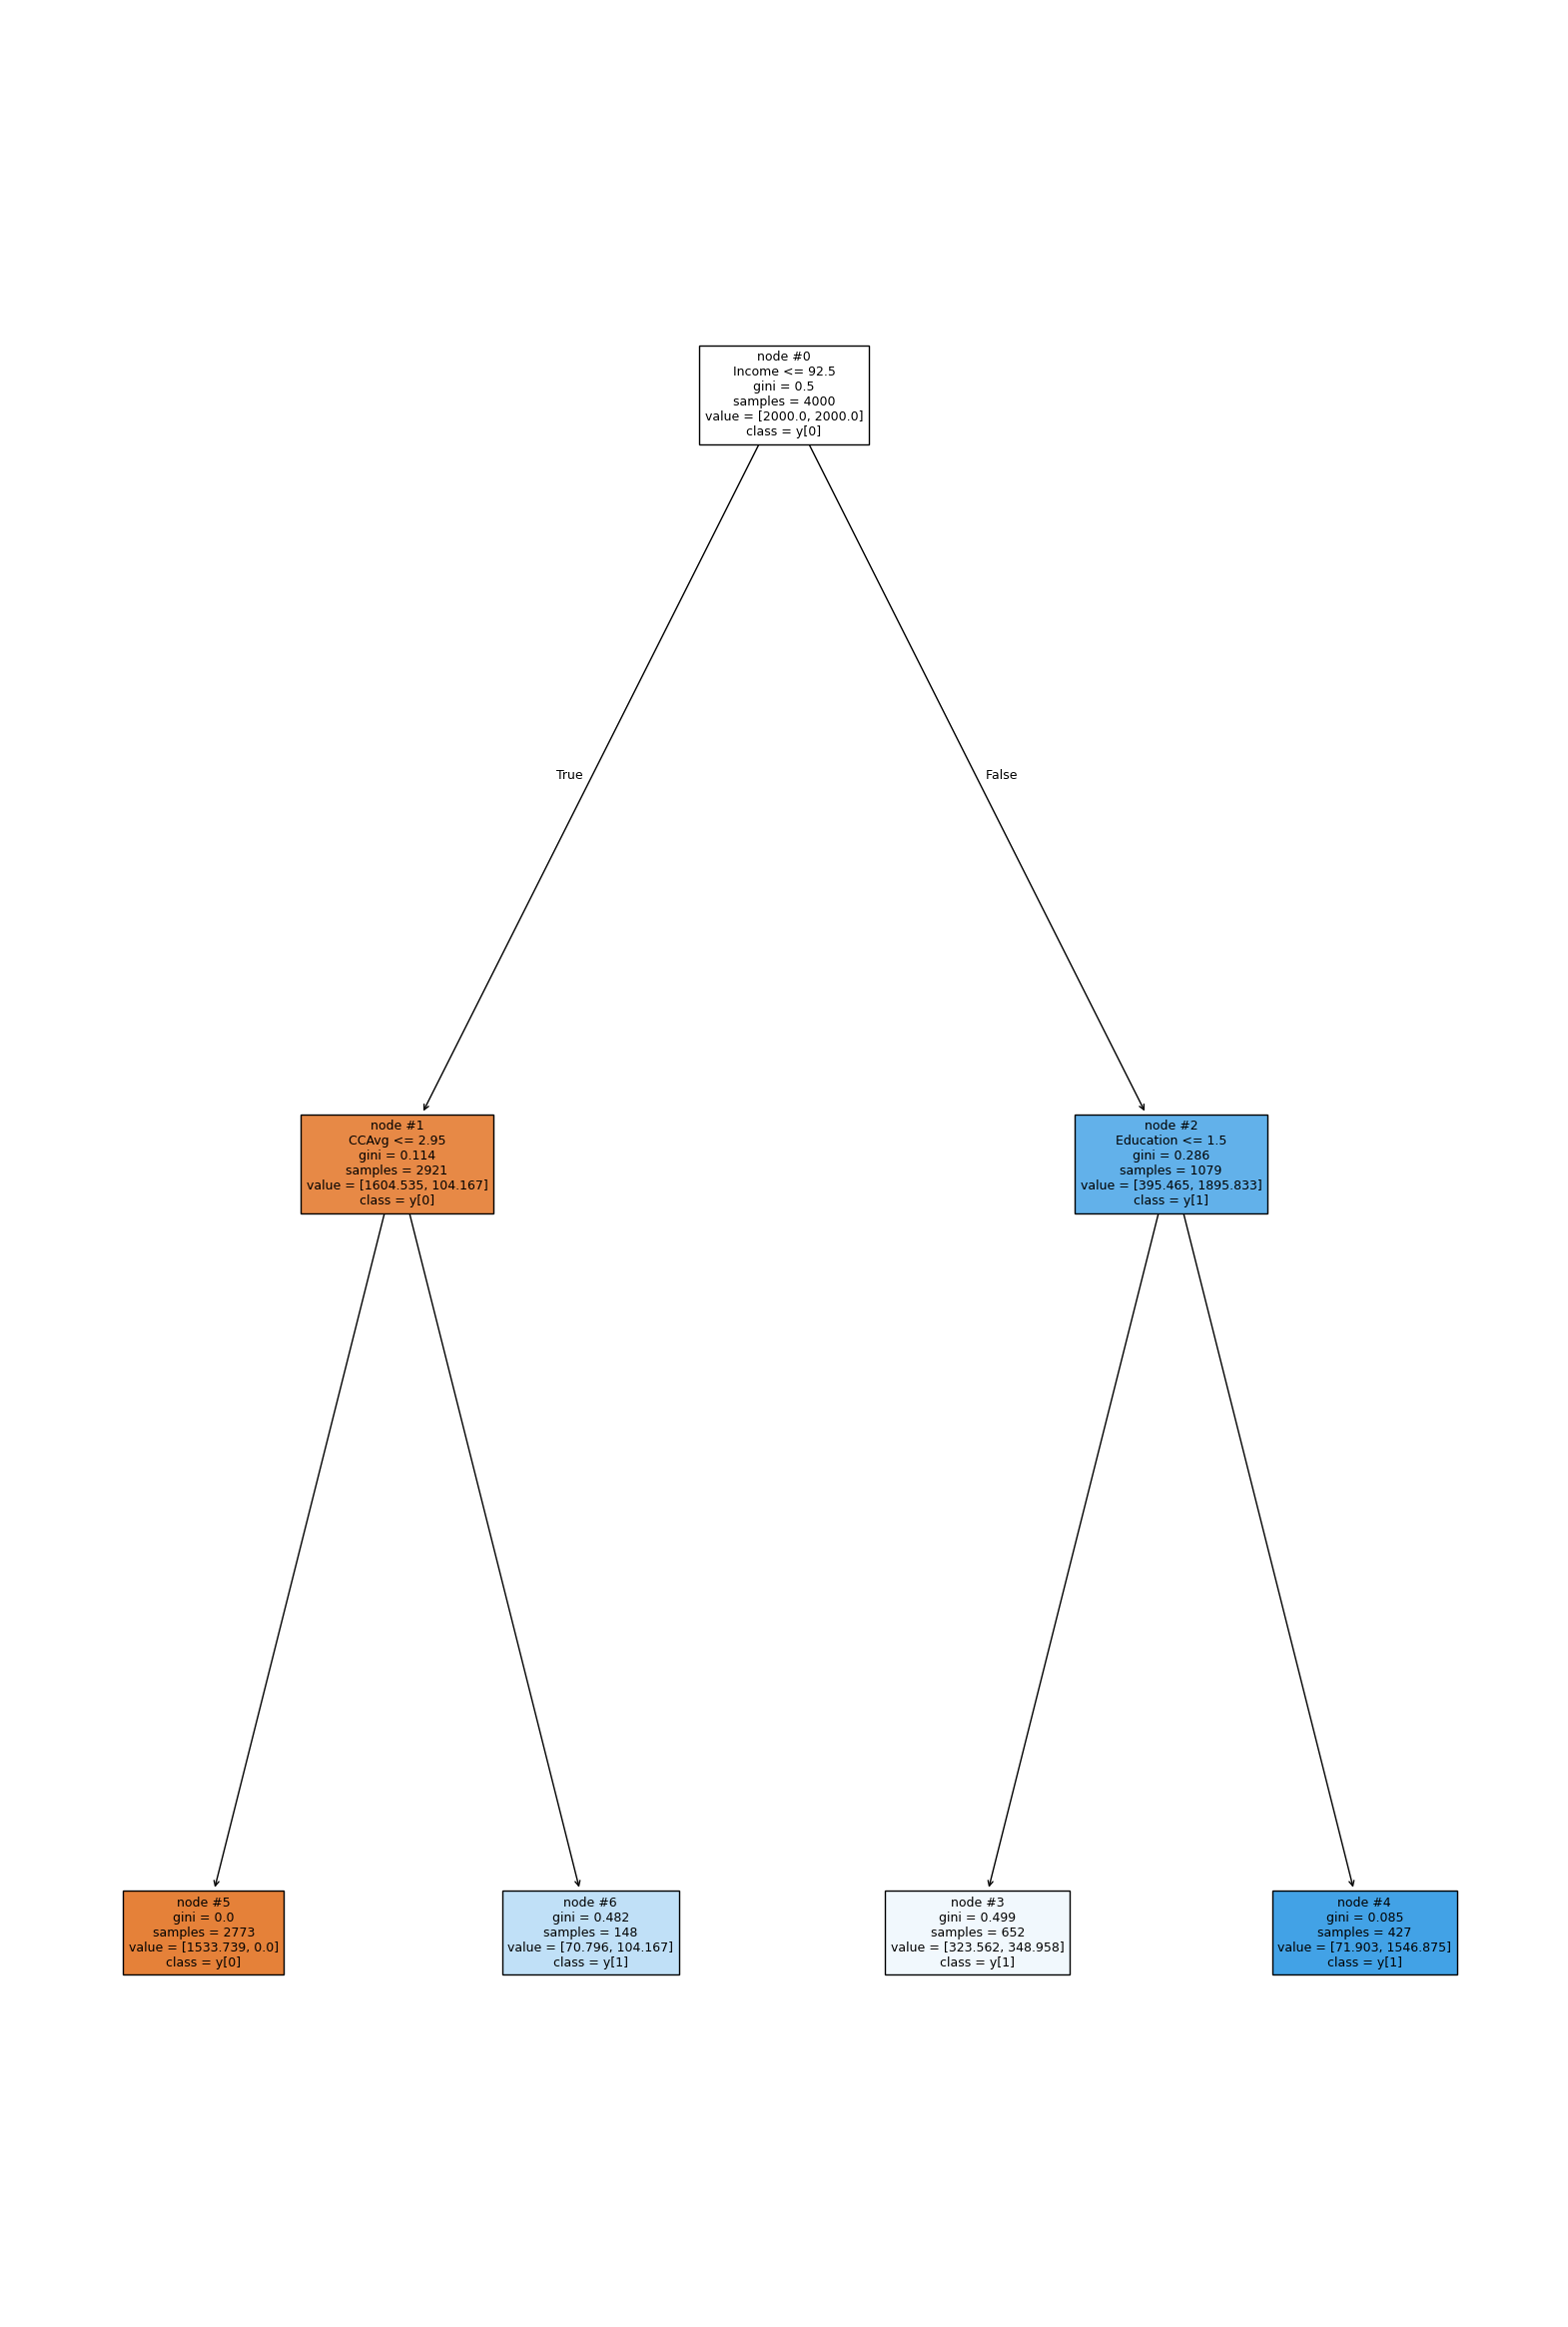

In [59]:
vtree(model1,x_test,y_train)

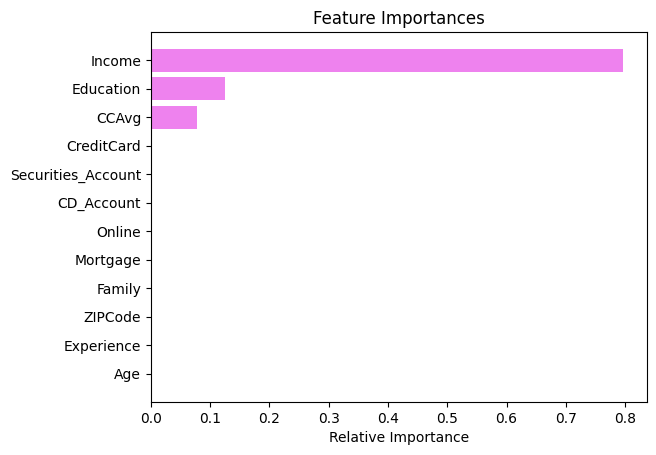

In [60]:
importance(model1,x_train,y_train)

## Decision Tree(Post-Pruning)

- Using Cost complexity pruning to reduce overfit and getting better model performance.

In [61]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

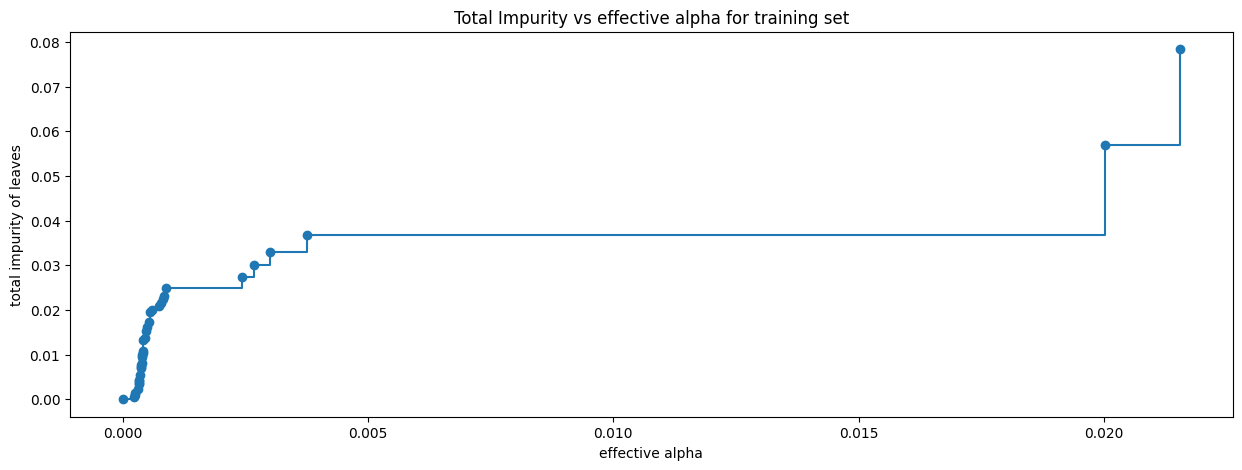

In [62]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [63]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(x_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.04760359071815694


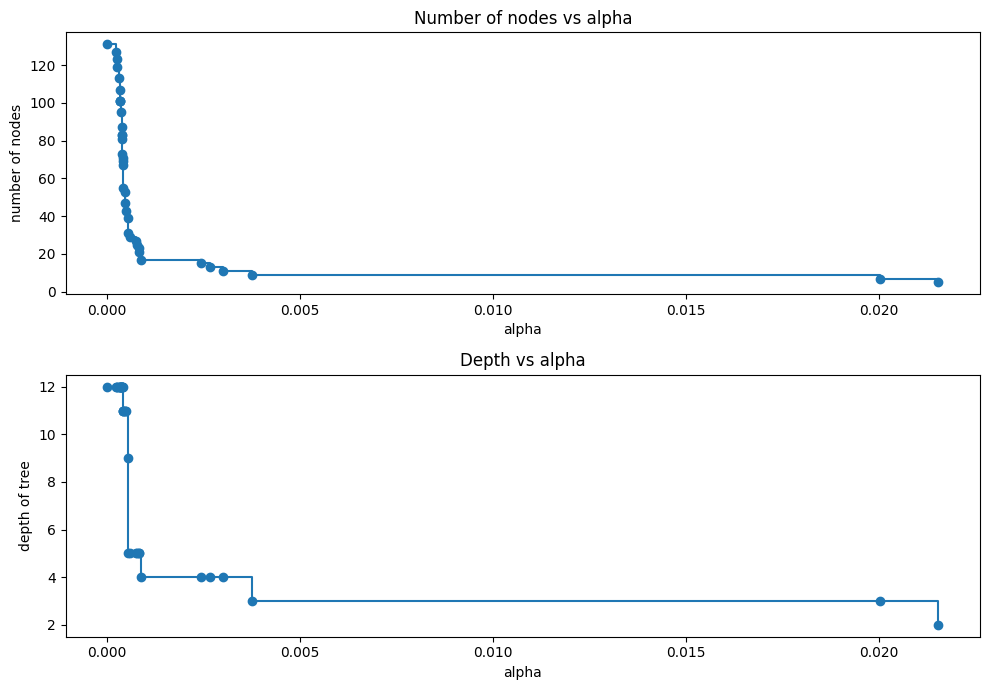

In [64]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [65]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(x_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [66]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(x_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

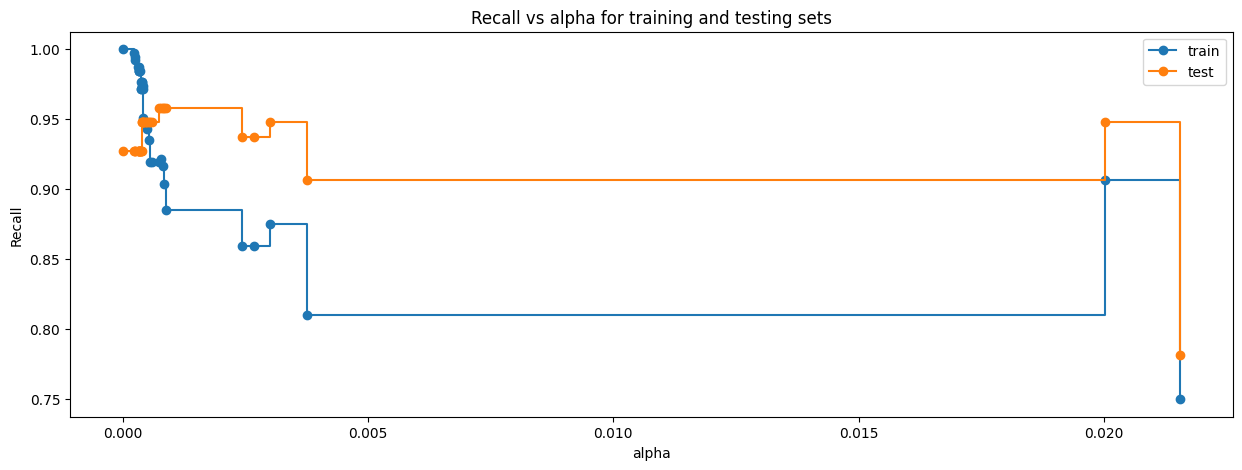

In [67]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [68]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0007452305246422896),
                       random_state=1)


   Accuracy    Recall  Precision        F1
0    0.9875  0.919271   0.948925  0.933862


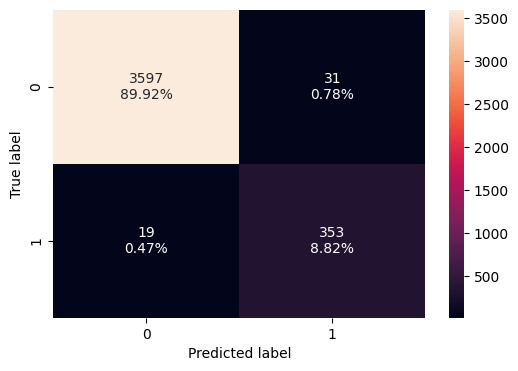

In [69]:
print(evaluation_metric(best_model,x_train,y_train))
confusion_matrix_sklearn(best_model,x_train,y_train)

   Accuracy    Recall  Precision        F1
0     0.985  0.958333   0.893204  0.924623


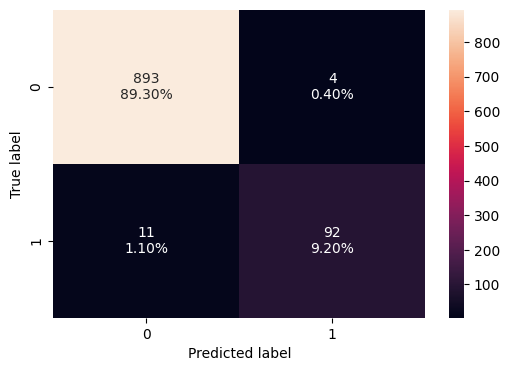

In [70]:
print(evaluation_metric(best_model,x_test,y_test))
confusion_matrix_sklearn(best_model,x_test,y_test)

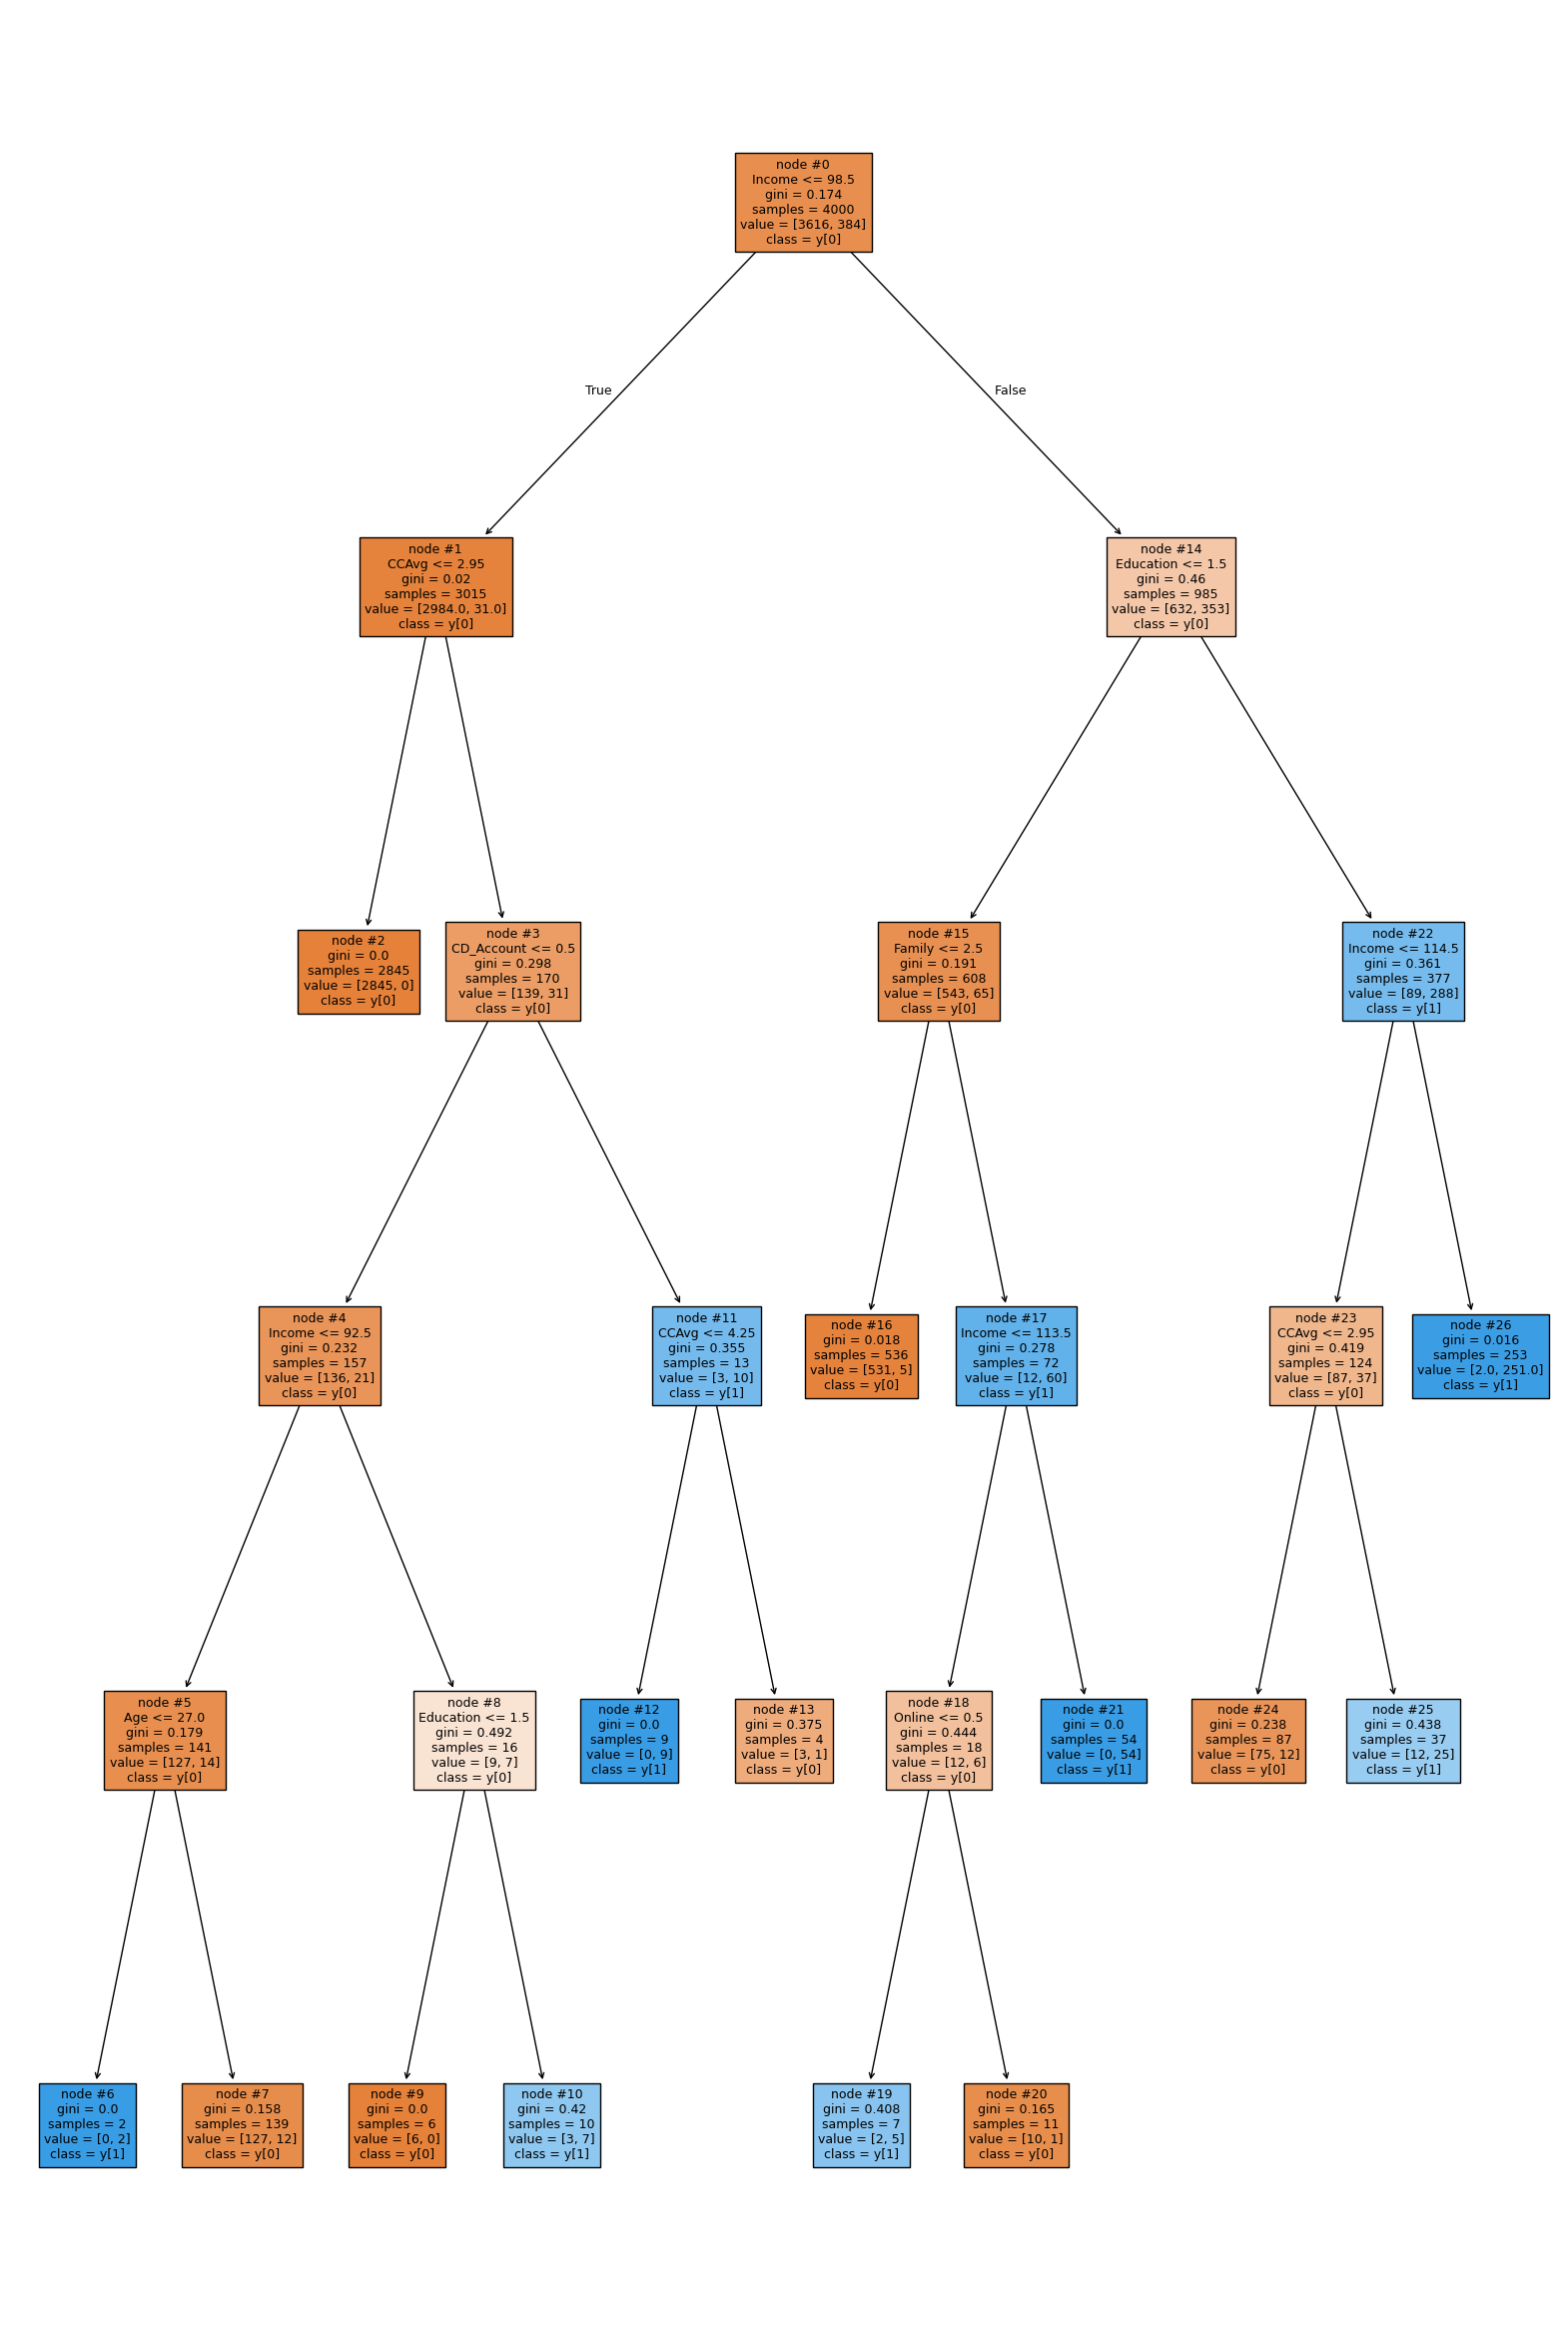

In [71]:
vtree(best_model,x_test,y_test)

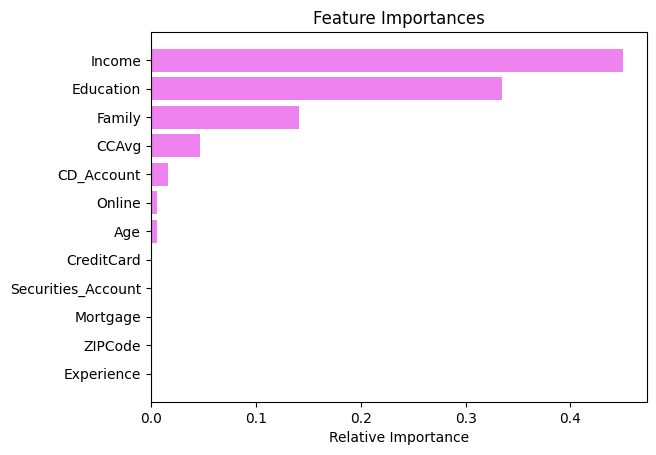

In [72]:
importance(best_model,x_test,y_test)

### Default vs Pre- Pruned vs Post Pruned Model Performance Comparison

In [73]:
decision_tree_default_perf_train = evaluation_metric(
    dtc, x_train, y_train
)

decision_tree_tune_perf_train = evaluation_metric(
    model1, x_train, y_train
)

decision_tree_postpruned_perf_train = evaluation_metric(
    best_model, x_train, y_train
)

In [74]:
decision_tree_default_perf_test = evaluation_metric(
    dtc, x_test, y_test
)

decision_tree_tune_perf_test = evaluation_metric(
    model1, x_test, y_test
)

decision_tree_postpruned_perf_test = evaluation_metric(
    best_model, x_test, y_test
)

In [75]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_postpruned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.789250,0.987500
Recall,1.0,1.000000,0.919271
Precision,1.0,0.312958,0.948925
F1,1.0,0.476723,0.933862


In [76]:
# test performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_postpruned_perf_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test performance comparison:")
models_test_comp_df


Test performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.984000,0.778000,0.985000
Recall,0.958333,1.000000,0.958333
Precision,0.884615,0.301887,0.893204
F1,0.920000,0.463768,0.924623


#### **Pre-Pruned Model have better Recall in both Training and Test data and hence will be recommended model for Loan Marketing Campaign.**

#### Segment Identification for Marketing Campaign.

In [77]:
dt["loan_prob"] = best_model.predict_proba(x)[:,1]
dt["Segment"] = pd.cut(
    dt["loan_prob"],
    bins=[0, 0.5, 0.8, 1],
    labels=["Low Potential", "Medium Potential", "High Potential"]
)
dt.groupby("Segment")[["Income","CCAvg","Education"]].mean().reset_index()


,Segment,Income,CCAvg,Education
0,Low Potential,125.519053,3.506540,1.355304
1,Medium Potential,104.109375,3.691719,2.312500
2,High Potential,152.374696,3.974988,2.243309


In [126]:
print("Customer with high loan probability",dt[(dt["Personal_Loan"]==1) & (dt["loan_prob"]>=0.8)].shape[0])

Customer with high loan probability 404


### Observation
- Out of 480 pre qualified customer who have taken the loan, best model predicted 404 customers out of this cohort.

<Axes: xlabel='Segment', ylabel='Income'>

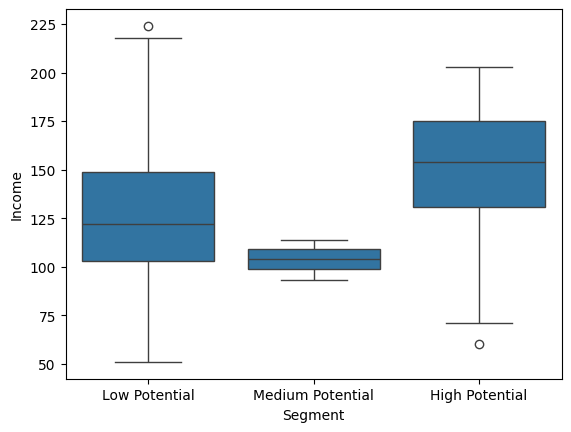

In [78]:
sns.boxplot(x="Segment", y="Income", data=dt)

<Axes: xlabel='Segment', ylabel='Education'>

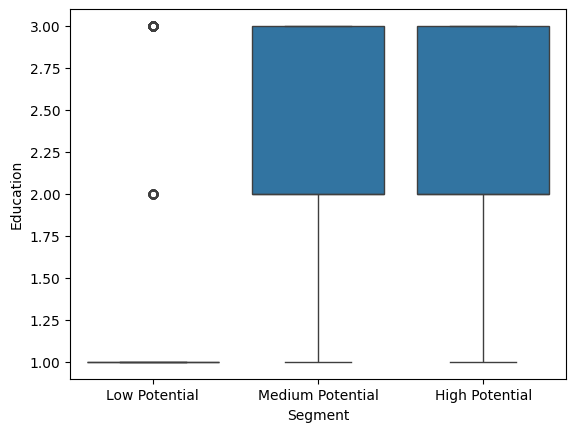

In [79]:
sns.boxplot(x="Segment", y="Education", data=dt)


<Axes: xlabel='Segment', ylabel='CCAvg'>

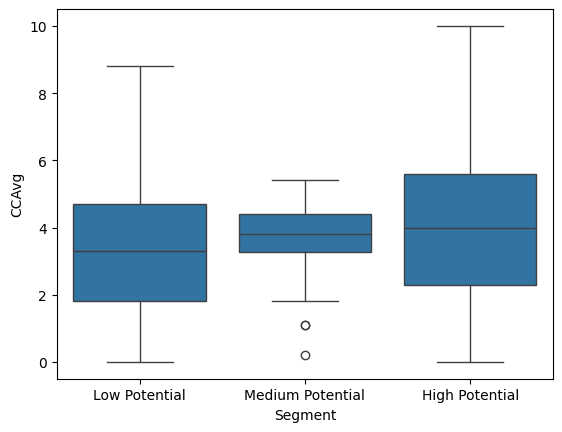

In [80]:
sns.boxplot(x="Segment", y="CCAvg", data=dt)

<Axes: xlabel='Segment', ylabel='CD_Account'>

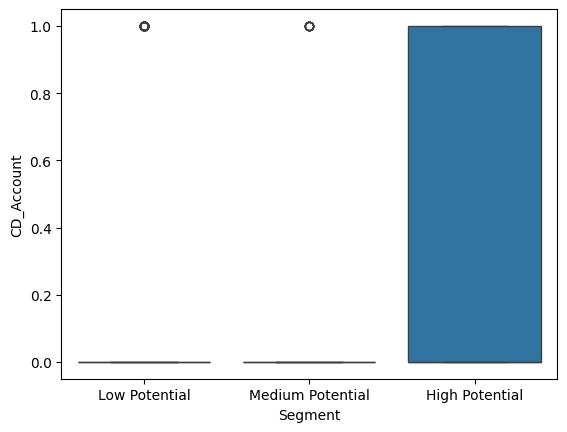

In [81]:
sns.boxplot(x="Segment", y="CD_Account", data=dt)


<Axes: xlabel='Income'>

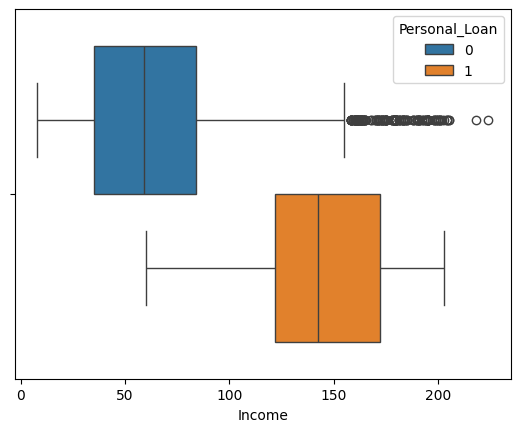

In [82]:
sns.boxplot(data=dt,x="Income",hue="Personal_Loan")

<Axes: xlabel='Education'>

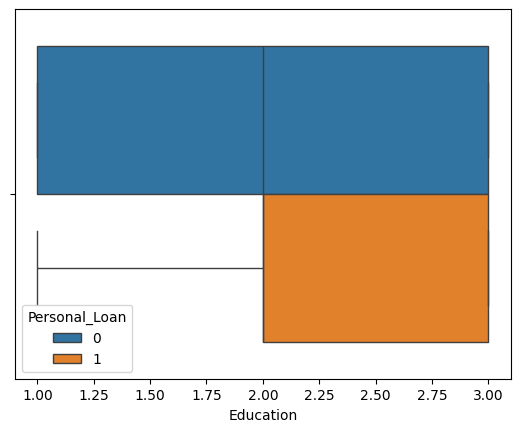

In [83]:

sns.boxplot(data=dt,x="Education",hue="Personal_Loan")

<Axes: xlabel='CCAvg'>

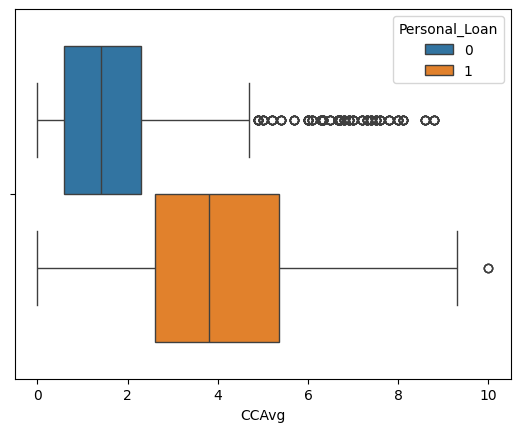

In [84]:
sns.boxplot(data=dt,x="CCAvg",hue="Personal_Loan")

## Marketing action:

High Potential segment from the model to target for Loan Marketing Campaign

Have:

- High Income, **$150k annually**

- Education level **2 or 3 (Graduate or Professional/Advanced)**

- High CCAv, **$4k per month** 

- Often hold CD accounts (from earlier analysis)